In [2]:
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 
import numpy as np 

In [3]:
df = pd.read_csv(r"C:\Users\saptu\Downloads\Fashion_company_data_set.csv", encoding="latin1")

In [4]:
df.head()

,company_id,company_name,total_revenue,fashion_style,company_regions,company_operated_retail_stores,founding_year,country_of_origin,years,revenue
0,1,Uniqlo,10500000000,CASUAL WEAR,"Uniqlo Japan, Uniqlo international, greater Ch...",175.0,1984,"tokyo,Japan",company_revenue_2012,5260000000
1,1,Uniqlo,10500000000,CASUAL WEAR,"Uniqlo Japan, Uniqlo international, greater Ch...",175.0,1984,"tokyo,Japan",company_revenue_2013,6350000000
2,1,Uniqlo,10500000000,CASUAL WEAR,"Uniqlo Japan, Uniqlo international, greater Ch...",175.0,1984,"tokyo,Japan",company_revenue_2014,7680000000
3,1,Uniqlo,10500000000,CASUAL WEAR,"Uniqlo Japan, Uniqlo international, greater Ch...",175.0,1984,"tokyo,Japan",company_revenue_2015,9410000000
4,1,Uniqlo,10500000000,CASUAL WEAR,"Uniqlo Japan, Uniqlo international, greater Ch...",175.0,1984,"tokyo,Japan",company_revenue_2016,9900000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 10 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   company_id                      156 non-null    int64  
 1   company_name                    156 non-null    object 
 2   total_revenue                   156 non-null    int64  
 3   fashion_style                   156 non-null    object 
 4   company_regions                 156 non-null    object 
 5   company_operated_retail_stores  156 non-null    float64
 6   founding_year                   156 non-null    int64  
 7   country_of_origin               156 non-null    object 
 8   years                           156 non-null    object 
 9   revenue                         156 non-null    int64  
dtypes: float64(1), int64(4), object(5)
memory usage: 12.3+ KB


In [6]:
df.describe()

,company_id,total_revenue,company_operated_retail_stores,founding_year,revenue
count,156.000000,1.560000e+02,156.000000,156.000000,1.560000e+02
mean,7.000000,1.230590e+10,139.839744,1956.153846,1.230654e+10
std,3.753708,1.107421e+10,123.922545,36.042655,1.150697e+10
min,1.000000,1.258483e+09,25.583333,1853.000000,4.730000e+08
25%,4.000000,3.898178e+09,50.750000,1949.000000,3.564250e+09
50%,7.000000,6.554167e+09,97.666667,1966.000000,6.395000e+09
75%,10.000000,2.058333e+10,175.000000,1974.000000,2.033750e+10
max,13.000000,3.700000e+10,1032.000000,1998.000000,5.154000e+10


In [7]:
df.isnull().sum()

company_id                        0
company_name                      0
total_revenue                     0
fashion_style                     0
company_regions                   0
company_operated_retail_stores    0
founding_year                     0
country_of_origin                 0
years                             0
revenue                           0
dtype: int64

In [8]:
df["fashion_style"].unique()

array(['CASUAL WEAR', 'CASUAL WEAR.', 'PREPPY', 'FAST FASHION',
       'MINIMALISM', 'ATHLEISURE', 'CHIC'], dtype=object)

Here, we have separated the columns for yearfrom the years coloumns which was attached with a name

In [9]:
df["year"] = df["years"].str.extract("(\d+)").astype(int)

In [10]:
df[["year","years"]].head()

,year,years
0,2012,company_revenue_2012
1,2013,company_revenue_2013
2,2014,company_revenue_2014
3,2015,company_revenue_2015
4,2016,company_revenue_2016


In [11]:
df["company_age"] = 2025-df["founding_year"]
#General age  of a company

In [12]:
df[["founding_year","company_age"]].head()

,founding_year,company_age
0,1984,41
1,1984,41
2,1984,41
3,1984,41
4,1984,41


In [13]:
df.groupby("fashion_style")["revenue"].std()

fashion_style
ATHLEISURE      9.792388e+09
CASUAL WEAR     5.242760e+09
CASUAL WEAR.    1.838043e+09
CHIC            9.594750e+08
FAST FASHION    5.620078e+09
MINIMALISM      1.458518e+09
PREPPY          8.554898e+08
Name: revenue, dtype: float64

In [14]:
df.groupby("company_name")["revenue"].max().sort_values(ascending=False)
#revenue by company in descending order 

company_name
Nike                  51540000000
Zara                  38290000000
Adidas                26430000000
H&M                   22420000000
Gap                   16700000000
Uniqlo                15830000000
Lululemon              8111000000
Ralph Lauren           7620000000
Levi's                 6180000000
Prada                  5070000000
Tommy Hilfiger         4800000000
Yves Saint Laurent     3300000000
Bottega Veneta         1740000000
Name: revenue, dtype: int64

Q.Which company has more retail_store?

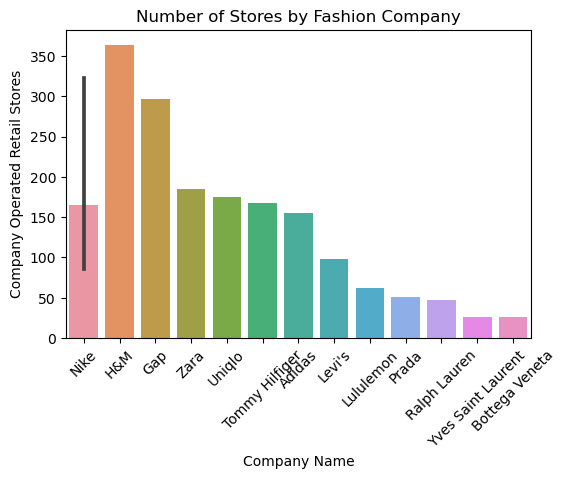

In [21]:
plt.figure(figsize=(6,4))
sns.barplot(x="company_name", y="company_operated_retail_stores", data=df.sort_values(by="company_operated_retail_stores",ascending=False))
plt.xticks(rotation=45)
plt.title("Number of Stores by Fashion Company")
plt.xlabel("Company Name")
plt.ylabel("Company Operated Retail Stores")

plt.show()

Q.Which company dominated the market?

In [19]:
top10 = df.groupby("company_name")["total_revenue"].max().nlargest(10).reset_index()
print(top10)
#Top 10 companies by revenue

     company_name  total_revenue
0            Nike    37000000000
1            Zara    28000000000
2          Adidas    22416666667
3             H&M    20583333333
4             Gap    15750000000
5          Uniqlo    10500000000
6    Ralph Lauren     6554166666
7          Levi's     5155833333
8           Prada     3958333333
9  Tommy Hilfiger     3898177500


Now, we will visualize it

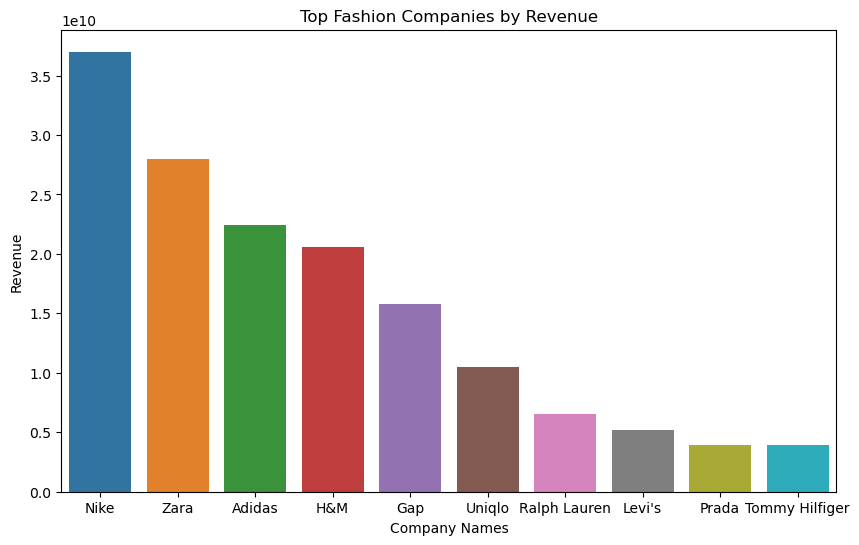

In [46]:
plt.figure(figsize=(10,6))
sns.barplot(x="company_name",y="total_revenue",data=top10)
plt.title("Top Fashion Companies by Revenue")
plt.xlabel("Company Names")
plt.ylabel("Revenue")

plt.show()

Q. Do older companies earn more revenue?

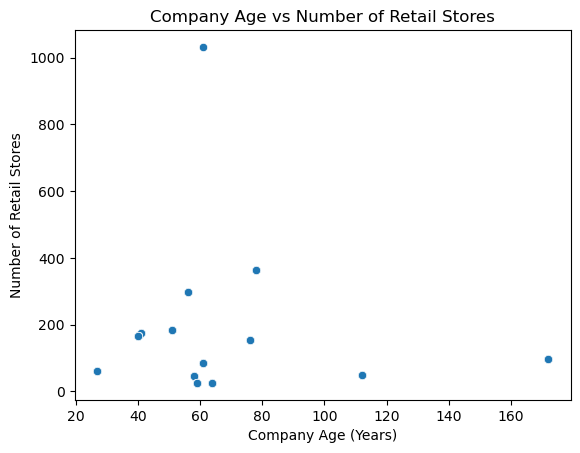

In [53]:
sns.scatterplot(x="company_age", y="company_operated_retail_stores", data=df)

plt.title("Company Age vs Number of Retail Stores")
plt.xlabel("Company Age (Years)")
plt.ylabel("Number of Retail Stores")

plt.show()

Q. Which style Dominates the fashion industry?

In [25]:
df["fashion_style"] = df["fashion_style"].str.replace(".", "", regex=False)

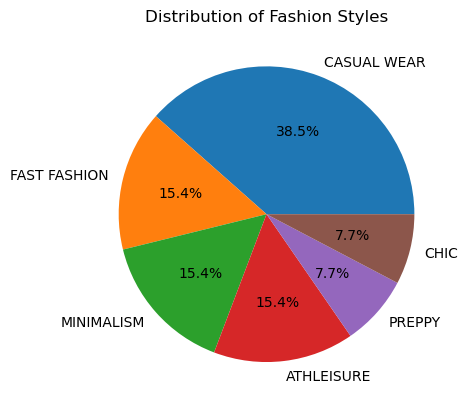

In [26]:
style_counts = df["fashion_style"].value_counts()
plt.pie(style_counts, labels=style_counts.index, autopct="%1.1f%%")
plt.title("Distribution of Fashion Styles")
plt.show()

In [68]:
df.columns

Index(['company_id', 'company_name', 'total_revenue', 'fashion_style',
       'company_regions', 'company_operated_retail_stores', 'founding_year',
       'country_of_origin', 'years', 'revenue', 'year', 'company_age',
       'country'],
      dtype='object')

In [63]:
df["country_of_origin"].head()

0    tokyo,Japan
1    tokyo,Japan
2    tokyo,Japan
3    tokyo,Japan
4    tokyo,Japan
Name: country_of_origin, dtype: object

Found out that we have region with state and country but not in different columns so separated them

In [66]:
df["country"] = df["country_of_origin"].str.split(",").str[1].str.strip()
country_rev = df.groupby("country")["total_revenue"].sum().reset_index()
print(country_rev)

    country  total_revenue
0  Germany.   269000000004
1    Italy.    62601799992
2     Japan   164850000000
3    Spain.   336000000000
4   Sweden.   246999999996
5      USA.   820298129988


Q. Which country has the oldest company?


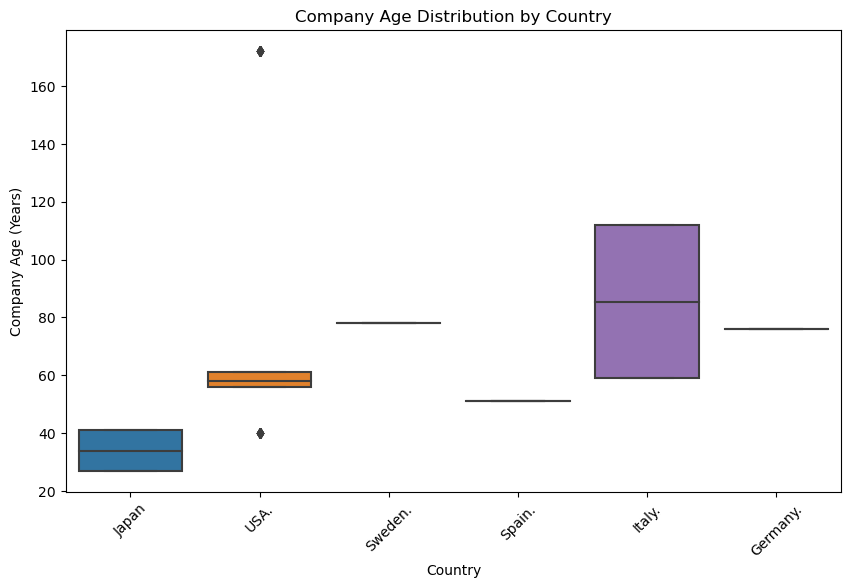

In [70]:
plt.figure(figsize=(10,6))
sns.boxplot(x="country", y="company_age", data=df)
plt.title("Company Age Distribution by Country")
plt.xlabel("Country")
plt.ylabel("Company Age (Years)")
plt.xticks(rotation=45)

plt.show()

Italy has the oldest fashion companies on average.

USA has some extremely old brands (outliers).

Japan has comparatively younger companies.

Some countries (Sweden, Spain, Germany) show less variation than can be possibly due to fewer companies in the dataset.

Q. WHat is the revenue progress in the fashion industry?


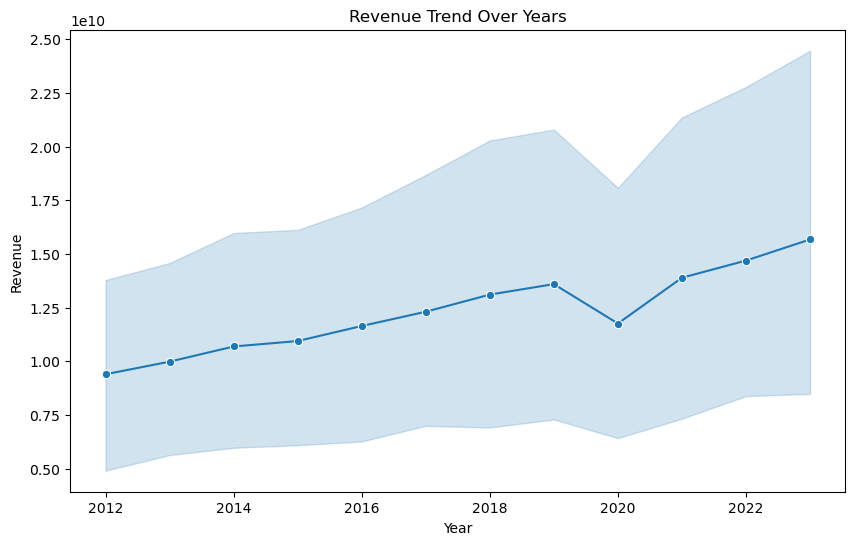

In [71]:
plt.figure(figsize=(10,6))
sns.lineplot(x="year", y="revenue", data=df, marker="o")
plt.title("Revenue Trend Over Years")
plt.xlabel("Year")
plt.ylabel("Revenue")

plt.show()

Q.Show the correlation beetween the total revenue, Retail stores, founding year, revenue, year,company age.

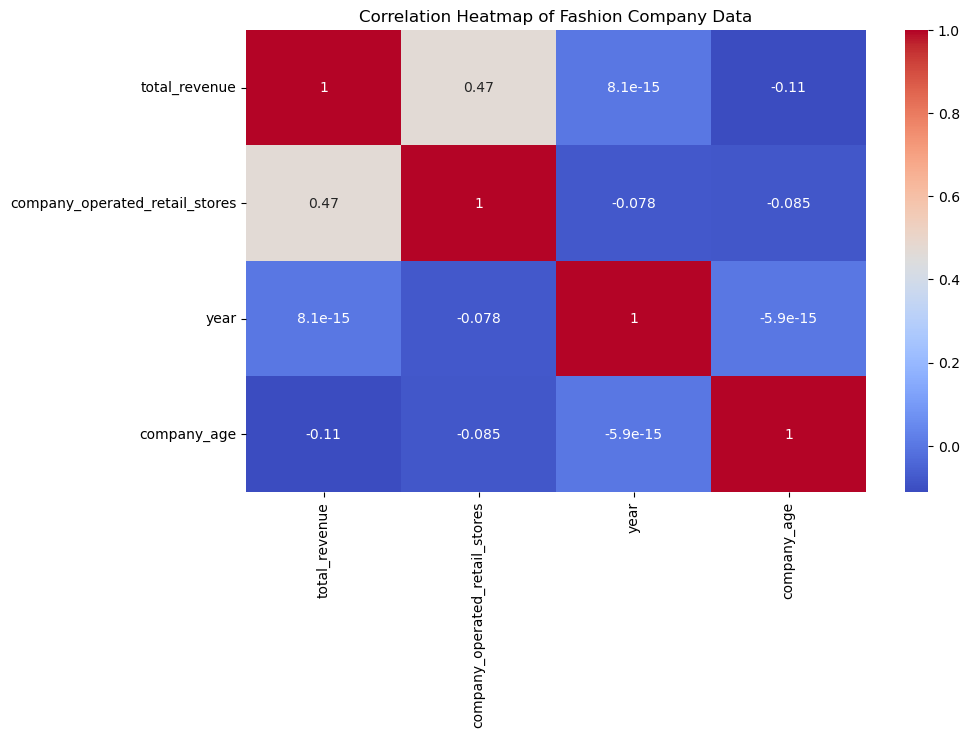

In [76]:

plt.figure(figsize=(10,6))

corr = df[["total_revenue","company_operated_retail_stores","year","company_age"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap of Fashion Company Data")
plt.show()

Total Revenue vs Retail Stores:
    If correlation is 0.7 or higher, companies with more stores tend to generate higher revenue.
Company Age vs Total Revenue:
    Older brands may have stronger brand recognition and higher revenue.
Year vs Revenue:
    A positive correlation means revenue tends to increase over the years.
Company Age vs Retail Stores:
    Older companies may have had more time to expand stores globally.